# Evaluation Metrics for Generative Modeling on Spatial Transcriptomics
**Data:** paired spatial-transcriptomics slides (Zhuang ABCA mouse-brain atlas).

A runnable companion to the `paired_slides_eval` suite. The notebook follows one linear workflow:

1. **Generate cells to evaluate** — confirm or regenerate per-model `.h5ad` artifacts.
2. **Build source, target, and classifier slide pickles** in one shared whitened `X_pca(50)` basis.
3. **Train the classifier probes** used by `ct/*` and `recon/*`.
4. **Train OT-CFM on the shared basis** — export `shared_pca.npz` from `abca_pair.pkl`, then train OT-CFM against it.
5. **Train NicheFlow VFM and CFM** — keep NicheFlow in the same pair preprocessing frame.
6. **Run evaluation, tables, and UMAP** from the shared target frame.

Everything is scored through the **same** apparatus. OT-CFM emits flat cells in the shared PCA coordinate convention, while NicheFlow emits niche-shaped cells with fixed target-centroid ground truth. During classifier/reconstruction evaluation, flat OT-CFM slides are now paired to the same fixed target centroids by OT assignment in the standardised coordinate frame. All paths below are **relative to `notebooks/`**.


## 0. Environment setup

Per-project `uv` venv (run from the `eval_metrics/` repo root):

In [15]:
%%bash
UV_LINK_MODE=copy uv sync --extra pipeline --extra nicheflow --extra classifier 

Resolved 268 packages in 1ms
Checked 245 packages in 96ms


In [16]:
%%bash
cd /work/magroup/shared/enfuzers/generative_modeling/eval_metrics
# env -u VIRTUAL_ENV uv run python -m ipykernel install --user \
#     --name eval_metrics --display-name "Python (eval_metrics)"

In [2]:
import sys, torch
print(sys.executable)
print(torch.__version__, torch.version.cuda)

/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/bin/python3
2.12.1+cu126 12.6


In [1]:
import importlib

import numpy as np
import pandas as pd


def _has(mod):
    try:
        importlib.import_module(mod)
        return True
    except Exception:
        return False


print("optional backends present:")
print("  torch   (MMD / EMD / classifier):", _has("torch"))
print("  ot/pot  (EMD / Wasserstein)     :", _has("ot"))
print("  squidpy (Moran's I)             :", _has("squidpy"))

optional backends present:
  torch   (MMD / EMD / classifier): True
  ot/pot  (EMD / Wasserstein)     : True
  squidpy (Moran's I)             : False


## 1. Generate cells to evaluate

The metrics compare the real **target slide** against a model's **generated cells**. This section is for checking or regenerating the `.h5ad` artifacts that evaluation consumes.

| key | emits | eval-time pairing |
|---|---|---|
| `otcfm` / `otcfm_spatial` | flat shared-PCA cells + 2D coords | fixed target centroids matched to generated cells by OT |
| `nicheflow_cfm` / `nicheflow_vfm` | niche-shaped shared-PCA cells + 2D coords | model-supplied `gt_x/gt_pos/gt_ct` at fixed target centroids |

The first cell checks the files. The following optional cells regenerate artifacts from existing checkpoints; run the relevant training sections first if you need new checkpoints.


In [ ]:
import os

# Each model's generated cells (one flat/niche .h5ad per model).
ARTIFACTS = {
    "otcfm":          "../artifacts/otcfm_shared50_1025/generated.h5ad",               
    "otcfm_spatial":  "../artifacts/otcfm_spatial_shared50_1025/generated.h5ad",       
    "nicheflow_cfm":  "../artifacts/nicheflow_cfm_unaligned/generated.h5ad",  
    "nicheflow_vfm":  "../artifacts/nicheflow_vfm_unaligned/generated.h5ad",           
}
for name, path in ARTIFACTS.items():
    print(f"{'OK     ' if os.path.exists(path) else 'MISSING'}  {name:14s} {path}")

In [19]:
%%bash
# OPTIONAL — (re)generate NicheFlow CFM cells on the allocated GPU (overwrites the artifact; needs a
# checkpoint).
cd ..
# uv run python -m paired_slides_eval.generate generator=nicheflow \
#     source=../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.024.h5ad \
#     target=../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
#     checkpoint=ckpts/NicheFlow_CFM_ABCA.ckpt \
#     generated_out=artifacts/nicheflow_cfm_unaligned/generated.h5ad
../nicheflow_mba/.venv/bin/python -m paired_slides_eval.generate generator=nicheflow \
      source=../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.024.h5ad \
      target=../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
      checkpoint=../nicheflow_mba/ckpts/NicheFlow_CFM_ABCA.ckpt \
      generated_out=artifacts/nicheflow_cfm_unaligned/generated.h5ad

[14:27:51][paired_slides_eval.adapters.nicheflow.h5ad_preprocessor][INFO] Preprocessing the spatial coordinates per timepoint with: standardization
[14:27:51][paired_slides_eval.adapters.nicheflow.h5ad_preprocessor][WARNING] Using `CPU`! Might be too slow!


Computing radius graphs for timepoint: 'B': 100%|██████████| 2/2 [00:06<00:00,  3.47s/it]
Subsampling centroids t='B' | dx=0.15 | dy=0.2: 100%|██████████| 2/2 [00:00<00:00, 37.68it/s]


[14:27:58][paired_slides_eval.adapters.nicheflow.h5ad_preprocessor][INFO] Fixing test microenvironments to 513 per slice.
[14:28:05][nicheflow.datasets.st_dataset_base][INFO] [rank: 0] Creating per timepoint PyTorch Geoemtric Data objects


/work/magroup/shared/enfuzers/generative_modeling/nicheflow_mba/.venv/lib/python3.12/site-packages/torchdyn/numerics/odeint.py:83: UserWarning: Setting tolerances has no effect on fixed-step methods
  warn("Setting tolerances has no effect on fixed-step methods")


Your vector field does not have `nn.Parameters` to optimize.
generated: 513 niches x 68 points -> artifacts/nicheflow_cfm_unaligned/generated.h5ad


In [21]:
%%bash
# Generate Nicheflow VFM cells 
cd ..
../nicheflow_mba/.venv/bin/python -m paired_slides_eval.generate generator=nicheflow \
      generator.variant=vfm \
      source=../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.024.h5ad \
      target=../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
      checkpoint=../nicheflow_mba/ckpts/NicheFlow_VFM_ABCA.ckpt \
      generated_out=artifacts/nicheflow_vfm_unaligned/generated.h5ad

[14:42:44][paired_slides_eval.adapters.nicheflow.h5ad_preprocessor][INFO] Preprocessing the spatial coordinates per timepoint with: standardization
[14:42:44][paired_slides_eval.adapters.nicheflow.h5ad_preprocessor][WARNING] Using `CPU`! Might be too slow!


Computing radius graphs for timepoint: 'B': 100%|██████████| 2/2 [00:06<00:00,  3.42s/it]
Subsampling centroids t='B' | dx=0.15 | dy=0.2: 100%|██████████| 2/2 [00:00<00:00, 37.88it/s]


[14:42:51][paired_slides_eval.adapters.nicheflow.h5ad_preprocessor][INFO] Fixing test microenvironments to 513 per slice.
[14:42:58][nicheflow.datasets.st_dataset_base][INFO] [rank: 0] Creating per timepoint PyTorch Geoemtric Data objects


/work/magroup/shared/enfuzers/generative_modeling/nicheflow_mba/.venv/lib/python3.12/site-packages/torchdyn/numerics/odeint.py:83: UserWarning: Setting tolerances has no effect on fixed-step methods
  warn("Setting tolerances has no effect on fixed-step methods")


Your vector field does not have `nn.Parameters` to optimize.
generated: 513 niches x 68 points -> artifacts/nicheflow_vfm_unaligned/generated.h5ad


In [42]:
%%bash
# OPTIONAL — (re)generate the OT-CFM cells from checkpoints trained in §4.
# The generator keeps expression in the model's shared whitened-PCA space; evaluation then
# auto-detects that the width already matches the target PCA basis and passes it through.
cd ..
FM=../fm_mnist
DATA=../nicheflow_mba/data

uv run python -m paired_slides_eval.generate generator=otcfm \
    target=$DATA/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
    source=null \
    checkpoint=$FM/outputs/cfm_shared50_1025/ckpt_final.pt \
    generator.fm_root=$FM \
    generated_out=artifacts/otcfm_shared50_1025/generated.h5ad

uv run python -m paired_slides_eval.generate generator=otcfm_spatial \
    source=$DATA/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
    target=$DATA/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
    checkpoint=$FM/outputs/cfm_spatial_shared50_1025/ckpt_final.pt \
    generator.fm_root=$FM \
    generated_out=artifacts/otcfm_spatial_shared50_1025/generated.h5ad


generated: 9962 cells, 50 feats (flat slide) -> artifacts/otcfm_shared50_1025/generated.h5ad


generated: 9962 cells, 50 feats (flat slide) -> artifacts/otcfm_spatial_shared50_1025/generated.h5ad


## 2. Build the source, target, and classifier slide pickles

One `preprocess_pair` fit defines the shared measuring apparatus and is reused everywhere:

- **Expression:** `normalize_total → log1p → shared PCA (fit on source+target) → whiten`.
- **Coordinates:** per-slide standardisation `(pos − mean) / std`.
- **Fixed target centroids:** `subsampled_timepoint_idx` is persisted and later used to pair flat OT-CFM slides to the same target centroid grid as NicheFlow.

| file | what it is |
|---|---|
| `../data/abca_pair.pkl` | the apparatus **and** the eval target — source `1.024` → target `1.025` |
| `../data/abca_1.026_clf.pkl` | the held-out **classifier** slide `1.026` projected into the *same* basis |

Slide identities: **target = `1.025`**, **generation pair = `1.024 → 1.025`**, **classifier slide = `1.026`**.


In [34]:
%%bash
uv run python -m paired_slides_eval.adapters.prepare_shared_slides \
  --source ../../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.024.h5ad \
  --target ../../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
  --classifier_slide ../../nicheflow_mba/data/adata_Zhuang_Zhuang-ABCA-1.026.h5ad \
  --ct_key class --n_pcs 50 \
  --out_pair ../data/abca_pair.pkl --out_classifier ../data/abca_1.026_clf.pkl

Using `CPU`! Might be too slow!
Computing radius graphs for timepoint: 'B': 100%|██████████| 2/2 [00:05<00:00,  2.68s/it]
Subsampling centroids t='B' | dx=0.15 | dy=0.2: 100%|██████████| 2/2 [00:00<00:00, 32.66it/s]
Using `CPU`! Might be too slow!
Computing radius graphs for timepoint: 'C': 100%|██████████| 1/1 [00:02<00:00,  2.35s/it]
Subsampling centroids t='C' | dx=0.15 | dy=0.2:   0%|          | 0/1 [00:00<?, ?it/s]You should change the values for `dx` and `dy`.GT: 9134 | Microenvironment cover: 9111
Subsampling centroids t='C' | dx=0.15 | dy=0.2: 100%|██████████| 1/1 [00:00<00:00, 22.06it/s]


saved shared pair -> ../data/abca_pair.pkl (target timepoint=B, n_pcs=50)
saved classifier slide -> ../data/abca_1.026_clf.pkl (9134 cells, 20 classes)


In [3]:
import pickle

ds = pickle.load(open("../data/abca_pair.pkl", "rb"))
print("shared whitened X_pca dim =", ds.X_pca.shape[1], "(the basis every model is scored in)")
print("target slide =", ds.timepoints_ordered[-1], "| cells =", ds.X_pca.shape[0])

shared whitened X_pca dim = 50 (the basis every model is scored in)
target slide = B | cells = 20104


In [ ]:
import pickle

from paired_slides_eval.adapters.nicheflow.preprocess import (
    preprocess_classifier_slide, preprocess_pair,
)

D = "../../nicheflow_mba/data"
SOURCE_H5AD     = f"{D}/adata_Zhuang_Zhuang-ABCA-1.024.h5ad"   # source (A)
TARGET_H5AD     = f"{D}/adata_Zhuang_Zhuang-ABCA-1.025.h5ad"   # target (B) = eval target
CLASSIFIER_H5AD = f"{D}/adata_Zhuang_Zhuang-ABCA-1.026.h5ad"   # held-out classifier slide
PAIR_PKL, CLF_PKL = "../data/abca_pair.pkl", "../data/abca_1.026_clf.pkl"
N_PCS, CT_KEY = 50, "class"

# In-process equivalent of the §2 CLI: fit the shared source+target PCA once; both the pair pickle
# (eval target) and the classifier slide land in that one whitened X_pca(50) basis.
ds_pair, pre = preprocess_pair(SOURCE_H5AD, TARGET_H5AD, n_pcs=N_PCS, cell_type_column=CT_KEY)
clf_ds = preprocess_classifier_slide(CLASSIFIER_H5AD, pre, cell_type_column=CT_KEY)
pickle.dump(ds_pair, open(PAIR_PKL, "wb"))
pickle.dump(clf_ds, open(CLF_PKL, "wb"))
print(f"built {PAIR_PKL} (X_pca dim={ds_pair.X_pca.shape[1]}) and {CLF_PKL} "
      f"({len(clf_ds.ct_ordered)} classes)")

## 3. Train the classifier probes

The label-free metrics (§6) run without trained probes. The `concordance` / `ct_gap` groups need one **`SpatialCTClassifierNet`**, trained on the classifier slide from §2 (`../data/abca_1.026_clf.pkl`) in the shared whitened **X_pca(50)** basis. This pair has **20** cell types, so override `data.n_classes=20`; `data.n_pcs=50` sets the net input dimension.

The `recon/*` group needs a second checkpoint: a masked-centroid expression regressor. It reuses `SpatialCTClassifierNet` with `output_dim = n_pcs`, but its dataset target is `target="expr"`, so it predicts the centroid expression from its KNN neighbours.


In [36]:
%%bash
# Runs on the job's GPU (kernel is inside the SLURM allocation). `cd ..` -> repo root so $PWD and the
# relative out-dirs match a terminal there. Both probes train in the shared whitened X_pca(50), so
# data.n_pcs=50 sets the nets' input_dim (and the regressor's output_dim) to match.
cd ..

# Cell-type classifier checkpoint (monitors val/f1) -> ckpts/clf_spatial.ckpt.
uv run python -m paired_slides_eval.classifier.train experiment=classifier/abca_spatial \
    data.datamodule.data_fp=$PWD/data/abca_1.026_clf.pkl data.n_classes=20 data.n_pcs=50 \
    logger=tensorboard hydra.run.dir=outputs/clf_gene_train

# Masked-centroid expression regressor checkpoint (monitors val/mse) -> ckpts/recon_spatial.ckpt.
uv run python -m paired_slides_eval.classifier.train experiment=classifier/abca_spatial_regressor \
    data.datamodule.data_fp=$PWD/data/abca_1.026_clf.pkl data.n_classes=20 data.n_pcs=50 \
    logger=tensorboard hydra.run.dir=outputs/recon_train

task_name: train                                                                
train: true                                                                     
test: true                                                                      
ckpt_path: null                                                                 
seed: '2025'                                                                    
data:                                                                           
  datamodule:                                                                   
    _target_: paired_slides_eval.classifier.datamodule.H5ADCTDataModule         
    split_seed: '2025'                                                          
    train_batch_size: 1024                                                      
    eval_batch_size: 1024                                                       
    num_workers: 2                                                              
    train_ratio: 0.8        

/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /work/magroup/shared/enfuzers/generative_modeling/e ...
Using bfloat16 Automatic Mixed Precision (AMP)
Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[08:50:49][__main__][INFO] [rank: 0] Logging hyperparameters!
[08:50:51][__main__][INFO] [rank: 0] Starting training!


/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /work/magroup/shared/enfuzers/generative_modeling/e ...
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /work/magroup/shared/enfuzers/generative_modeling/eval_metrics/outputs/clf_gene_train/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ net                               │ SpatialCT… │ 59.5 K │ train │     0 │
│ 1  │ net.point_proj                    │ Linear     │  3.3 K │ train │     0 │
│ 2  │ net.encoder                       │ Sequential │ 33.8 K │ train │     0 │
│ 3  │ net.encoder.0                     │ SAB        │ 16.9 K │ train │     0 │
│ 4  │ net.encoder.0.mab                 │ MAB        │ 16.9 K │ train │     0 │
│ 5  │ net.encoder.0.mab.fc_q            │ Linear     │  4.2 K │ train │     0 │
│ 6  │ net.encoder.0.mab.fc_k            │ Linear     │  4.2 K │ train │     0 │
│ 7  │ net.encoder.0.mab.fc_v            │ Linear     │  4.2 K │ train │     0 │
│ 8  │ net.encoder.0.mab.ln0             │ LayerNorm  │    128 │ train │     0 │
│ 9  │ net.encoder.0.mab.ln1

...

/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 8/8 [00:00<00:00, 23.21it/s, v_num=3, train/loss=0.916]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 8/8 [00:00<00:00, 33.62it/s, v_num=3, train/loss=0.898, val/mse=0.915]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 8/8 [00:00<00:00, 32.32it/s, v_num=3, train/loss=0.848, val/mse=0.875]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 8/8 [00:00<00:00, 31.73it/s, v_num=3, train/loss=0.852, val/mse=0.841]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 8/8 [00:00<00:00, 35.52it/s, v_num=3, train/loss=0.812, val/mse=0.815]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 8/8 [00:00<00:00, 32.44it/s, v_num=3, train/

Restoring states from the checkpoint path at /work/magroup/shared/enfuzers/generative_modeling/eval_metrics/outputs/recon_train/checkpoints/epoch_037-v1.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /work/magroup/shared/enfuzers/generative_modeling/eval_metrics/outputs/recon_train/checkpoints/epoch_037-v1.ckpt


Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 73.96it/s] 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mse          │    0.7840713858604431     │
└───────────────────────────┴───────────────────────────┘
[08:53:15][__main__][INFO] [rank: 0] Best ckpt path: /work/magroup/shared/enfuzers/generative_modeling/eval_metrics/outputs/recon_train/checkpoints/epoch_037-v1.ckpt
[08:53:15][__main__][INFO] [rank: 0] {'lr-AdamW': tensor(0.0004), 'train/loss': tensor(0.6888), 'val/mse': tensor(0.7890), 'test/mse': tensor(0.7841)}


In [37]:
%%bash
cd ../
mkdir -p ckpts
cp "$(ls -t outputs/clf_gene_train/checkpoints/epoch_*.ckpt | head -1)" ckpts/clf_gene.ckpt
cp "$(ls -t outputs/recon_train/checkpoints/epoch_*.ckpt | head -1)" ckpts/recon_spatial.ckpt
echo wrote ckpts/clf_gene.ckpt
echo wrote ckpts/recon_spatial.ckpt

wrote ckpts/clf_gene.ckpt
wrote ckpts/recon_spatial.ckpt


## 4. Train OT-CFM on the shared basis

### 4a. Build `shared_pca.npz` from `abca_pair.pkl`

Export the §2 shared PCA recipe into the format `fm_mnist` can replay. This keeps OT-CFM training in the same whitened `X_pca(50)` basis as evaluation and NicheFlow.

### 4b. Train OT-CFM on the shared basis

After exporting the basis, retrain OT-CFM with `--pca_stats`. The generator should keep the sampled expression in PCA space instead of inverting it back to raw genes.


In [40]:
%%bash
# Export §2's shared PCA as an fm_mnist load_spatial_pca stats .npz (CPU, light; eval venv).
cd ..
uv run python -m paired_slides_eval.adapters.otcfm_export \
    --pair data/abca_pair.pkl --out data/shared_pca.npz

wrote data/shared_pca.npz: k=50 PCs, 1122 genes, target_sum=310.0, coord_std=[0.49000000953674316, 0.7300000190734863]


In [41]:
%%bash
# Retrain OT-CFM IN the shared 50-d basis (gene-only + naive-spatial). Uses the root venv
# (.venv: torch + torchcfm + scanpy + sklearn); train_cfm_spatial.py self-adds fm to sys.path.
# Needs a GPU allocation. Keep your usual hyperparameters (--steps/--batch/--lr/--coupling/…);
# --n_pcs/--whiten/--target_sum are ignored once --pca_stats is given (dim auto = 50, or 52 with coords).
cd ../..                                     # -> generative_modeling/
PY=.venv/bin/python
DATA=nicheflow_mba/data
STATS=eval_metrics/data/shared_pca.npz

# gene-only  (-> feeds artifacts/otcfm_1025)
$PY fm_mnist/scripts/train_cfm_spatial.py \
    --data $DATA/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
    --pca_stats $STATS \
    --out fm_mnist/outputs/cfm_shared50_1025

# naive-spatial  (-> feeds artifacts/otcfm_spatial_1025)
$PY fm_mnist/scripts/train_cfm_spatial.py \
    --data $DATA/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
    --pca_stats $STATS --spatial_key spatial \
    --out fm_mnist/outputs/cfm_spatial_shared50_1025

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/qimow/.netrc.
wandb: Currently logged in as: qimow (qimow-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run thdmcsha
wandb: Tracking run with wandb version 0.27.0
wandb: Run data is saved locally in /work/magroup/shared/enfuzers/generative_modeling/wandb/run-20260703_090807-thdmcsha
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run jumping-butterfly-15
wandb: ⭐️ View project at https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial
wandb: 🚀 View run at https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial/runs/thdmcsha


train batches/epoch=35  test cells=996  PCA dim=50


loss=0.7853: 100%|██████████| 8000/8000 [02:04<00:00, 64.27it/s]
wandb: updating run metadata
wandb: uploading history steps 7422-7999, summary, console lines 1-3
wandb: 
wandb: Run history:
wandb: train/loss █▆▅▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▂▂▂
wandb:   train/lr ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb: train/loss 0.78573
wandb:   train/lr 0.002
wandb: 
wandb: 🚀 View run jumping-butterfly-15 at: https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial/runs/thdmcsha
wandb: ⭐️ View project at: https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260703_090807-thdmcsha/logs


saved checkpoints to fm_mnist/outputs/cfm_shared50_1025 (final: ckpt_final.pt @ step 8000)
evaluate with: python scripts/eval_cfm_spatial.py --checkpoint fm_mnist/outputs/cfm_shared50_1025/ckpt_final.pt


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/qimow/.netrc.
wandb: Currently logged in as: qimow (qimow-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run 7eemmnib
wandb: Tracking run with wandb version 0.27.0
wandb: Run data is saved locally in /work/magroup/shared/enfuzers/generative_modeling/wandb/run-20260703_091036-7eemmnib
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run denim-wave-16
wandb: ⭐️ View project at https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial
wandb: 🚀 View run at https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial/runs/7eemmnib


train batches/epoch=35  test cells=996  PCA dim=52


loss=0.7961: 100%|██████████| 8000/8000 [02:04<00:00, 64.35it/s]
wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 7596-7999, summary, console lines 1-3
wandb: 
wandb: Run history:
wandb: train/loss █▇▇▄▄▄▄▄▃▄▃▃▃▃▃▃▃▂▃▃▂▃▃▃▃▂▃▃▂▂▃▂▃▃▂▂▁▂▂▂
wandb:   train/lr ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb: train/loss 0.78093
wandb:   train/lr 0.002
wandb: 
wandb: 🚀 View run denim-wave-16 at: https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial/runs/7eemmnib
wandb: ⭐️ View project at: https://wandb.ai/qimow-carnegie-mellon-university/fm-spatial
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260703_091036-7eemmnib/logs


saved checkpoints to fm_mnist/outputs/cfm_spatial_shared50_1025 (final: ckpt_final.pt @ step 8000)
evaluate with: python scripts/eval_cfm_spatial.py --checkpoint fm_mnist/outputs/cfm_spatial_shared50_1025/ckpt_final.pt


## 5. Train NicheFlow VFM and CFM

Train NicheFlow against the same source→target pair used in §2. NicheFlow's preprocessing already produces whitened `X_pca(50)` expression, standardised 2D coordinates, and fixed target-centroid ground truth (`gt_x/gt_pos/gt_ct`) for generated niches.

The exact command can vary with the external `nicheflow_mba` checkout, so keep the project-specific training entrypoint here. After training, use the generation cells in §1 to write `artifacts/nicheflow_cfm_unaligned/generated.h5ad` and `artifacts/nicheflow_vfm_unaligned/generated.h5ad`.


In [ ]:
%%bash
# OPTIONAL — train NicheFlow CFM/VFM checkpoints in the external NicheFlow environment.
# Replace the command/module names with the current training entrypoint in ../nicheflow_mba.
cd ../../nicheflow_mba
# .venv/bin/python -m nicheflow.train variant=cfm \
#     data.source=data/adata_Zhuang_Zhuang-ABCA-1.024.h5ad \
#     data.target=data/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
#     trainer.default_root_dir=ckpts/NicheFlow_CFM_ABCA
# .venv/bin/python -m nicheflow.train variant=vfm \
#     data.source=data/adata_Zhuang_Zhuang-ABCA-1.024.h5ad \
#     data.target=data/adata_Zhuang_Zhuang-ABCA-1.025.h5ad \
#     trainer.default_root_dir=ckpts/NicheFlow_VFM_ABCA


## 6. Run evaluate and generate tables and UMAP

This is the same `python -m paired_slides_eval.evaluate` command you'd run in the terminal. Point every model at the **same** `data/abca_pair.pkl`; reconciliation into the shared space is automatic.

- **Expression** — already-reduced shared-PCA cells pass through; gene-space cells would project through the pickle's `SharedGenePCA`.
- **Coordinates** — `--coords auto` detects raw vs already-standardised coords and maps them into the target frame.
- **Flat-slide classifier pairing** — default `--flat_pairing fixed_target_ot` uses `subsampled_timepoint_idx` target centroids and OT-assigns them to generated cells, matching the NicheFlow target frame.

`--classifier` enables `ct/*`; `--ct_real_reference fixed` makes `ct/acc_real` one model-independent constant across the table. `--regressor` enables `recon/*`.


### 6a. Full metric suite → per-model CSV


In [5]:
%%bash
cd ..
CKPT=ckpts/clf_gene.ckpt
RECON=ckpts/recon_spatial.ckpt
CLF=""; [ -f "$CKPT" ] && CLF="--classifier $CKPT --ct_real_reference fixed"
REG=""; [ -f "$RECON" ] && REG="--regressor $RECON"
[ -z "$CLF" ] && echo "no classifier at $CKPT -> ct/* groups will skip"
[ -z "$REG" ] && echo "no regressor at $RECON -> recon/* group will skip"
METRIC_GROUPS="psd spd distribution c2st c2st_nn moran concordance ct_gap recon"
for m in otcfm_shared50_1025 otcfm_spatial_shared50_1025 nicheflow_cfm_unaligned nicheflow_vfm_unaligned; do
    echo "===== $m ====="
    uv run python -m paired_slides_eval.evaluate \
        --target data/abca_pair.pkl \
        --generated artifacts/$m/generated.h5ad \
        --ct_key class --flat_pairing fixed_target_ot --groups $METRIC_GROUPS $CLF $REG \
        --out reports/$m/metrics_npc50_new.csv
done

===== otcfm_shared50_1025 =====


<frozen runpy>:128: RuntimeWarning: 'paired_slides_eval.evaluate' found in sys.modules after import of package 'paired_slides_eval', but prior to execution of 'paired_slides_eval.evaluate'; this may result in unpredictable behaviour
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/src/paired_slides_eval/metrics/morans.py:43: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbor

INFO     Creating graph using `None` transform and `1` libraries.               


/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/src/paired_slides_eval/metrics/morans.py:43: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=n_neighs)


INFO     Creating graph using `None` transform and `1` libraries.               
target: 9962 cells, 50 features
generated: 9962 cells, 50 feats (flat slide)
test/c2st/acc            0.7310
test/c2st/auc            0.8004
test/c2st/gene_acc       0.6307
test/c2st/gene_auc       0.6710
test/c2st/nn             0.5183
test/c2st/nn_flip        0.4375
test/c2st/nn_real_ref    0.6718
test/c2st/nn_std         0.1652
test/c2st/pos_acc        0.6315
test/ct/acc              0.3314
test/ct/acc_gap          0.2840
test/ct/acc_gen          0.3060
test/ct/acc_real         0.5900
test/ct/f1               0.2647
test/ct/prop_jsd         0.0675
test/ct/prop_kl          0.4386
test/ct/prop_tv          0.2982
test/mmd2/pos            0.0661
test/mmd2/x              0.0060
test/moran/corr          -0.1422
test/moran/gen_mean      -0.0010
test/moran/mae           0.1897
test/moran/real_mean     0.1887
test/ot_w1/pos           0.4311
test/ot_w1/x             5.5172
test/ot_w2/pos           0.5063
test/ot_

...

INFO     Creating graph using `None` transform and `1` libraries.               
target: 9962 cells, 50 features
generated: 513 niches x 68 points
test/c2st/acc            0.9290
test/c2st/auc            0.9797
test/c2st/gene_acc       0.9387
test/c2st/gene_auc       0.9845
test/c2st/nn             0.0257
test/c2st/nn_flip        0.0000
test/c2st/nn_real_ref    0.9895
test/c2st/nn_std         0.0563
test/c2st/pos_acc        0.7027
test/ct/acc              0.2593
test/ct/acc_gap          0.3600
test/ct/acc_gen          0.2300
test/ct/acc_real         0.5900
test/ct/f1               0.2555
test/ct/prop_jsd         0.0118
test/ct/prop_kl          0.1601
test/ct/prop_tv          0.0936
test/mmd2/pos            0.0175
test/mmd2/x              0.0307
test/moran/corr          0.6882
test/moran/gen_mean      0.0818
test/moran/mae           0.1238
test/moran/real_mean     0.1887
test/ot_w1/pos           0.2954
test/ot_w1/x             7.2509
test/ot_w2/pos           0.3500
test/ot_w2/x         

<frozen runpy>:128: RuntimeWarning: 'paired_slides_eval.evaluate' found in sys.modules after import of package 'paired_slides_eval', but prior to execution of 'paired_slides_eval.evaluate'; this may result in unpredictable behaviour
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/src/paired_slides_eval/metrics/morans.py:43: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbor

INFO     Creating graph using `None` transform and `1` libraries.               


/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/src/paired_slides_eval/metrics/morans.py:43: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=n_neighs)


INFO     Creating graph using `None` transform and `1` libraries.               
target: 9962 cells, 50 features
generated: 513 niches x 68 points
test/c2st/acc            0.5912
test/c2st/auc            0.6137
test/c2st/gene_acc       0.5882
test/c2st/gene_auc       0.6218
test/c2st/nn             0.3209
test/c2st/nn_flip        0.1000
test/c2st/nn_real_ref    0.3896
test/c2st/nn_std         0.1728
test/c2st/pos_acc        0.5633
test/ct/acc              0.3996
test/ct/acc_gap          0.3288
test/ct/acc_gen          0.2612
test/ct/acc_real         0.5900
test/ct/f1               0.3721
test/ct/prop_jsd         0.0113
test/ct/prop_kl          0.0478
test/ct/prop_tv          0.1404
test/mmd2/pos            0.0381
test/mmd2/x              0.0045
test/moran/corr          0.9677
test/moran/gen_mean      0.1899
test/moran/mae           0.0251
test/moran/real_mean     0.1887
test/ot_w1/pos           0.2703
test/ot_w1/x             5.1645
test/ot_w2/pos           0.3314
test/ot_w2/x         

**Optional** — collate the per-model `metrics.csv` files the CLI just wrote into one wide
comparison table (`reports/model_comparison.csv`)

In [6]:
import glob
import os

import pandas as pd

cols = {}
for csv_path in sorted(glob.glob("../reports/*/metrics_npc50_new.csv")):
    name = os.path.basename(os.path.dirname(csv_path))
    cols[name] = pd.read_csv(csv_path, index_col="metric")["value"]
table = pd.DataFrame(cols).sort_index()
table.to_csv("../reports/model_comparison_shared50_new.csv")
print("wrote ../reports/model_comparison_shared50_new.csv")
table

wrote ../reports/model_comparison_shared50_new.csv


,nicheflow_cfm_unaligned,nicheflow_vfm_unaligned,otcfm_shared50_1025,otcfm_spatial_shared50_1025
metric,,,,
test/c2st/acc,0.929000,0.591250,0.731000,0.654000
test/c2st/auc,0.979723,0.613660,0.800386,0.697085
test/c2st/gene_acc,0.938750,0.588250,0.630750,0.652000
test/c2st/gene_auc,0.984546,0.621823,0.671011,0.694842
test/c2st/nn,0.025700,0.320900,0.518300,0.548450
test/c2st/nn_flip,0.000000,0.100000,0.437500,0.513000
test/c2st/nn_real_ref,0.989550,0.389600,0.671850,0.705600
test/c2st/nn_std,0.056298,0.172810,0.165152,0.158706
test/c2st/pos_acc,0.702750,0.563250,0.631500,0.552250


### 6b. A single model / subset of groups → print

Drop `--out` and the CLI just prints the metrics plus notes. Available groups: `psd`, `spd`, `distribution`, `c2st`, `c2st_nn`, `moran`, and — with `--classifier` / `--regressor` — `concordance`, `ct_gap`, `recon`.


In [ ]:
%%bash
cd ..
python -m paired_slides_eval.evaluate \
    --target data/abca_pair.pkl \
    --generated artifacts/otcfm_spatial_shared50_1025/generated.h5ad \
    --classifier ckpts/clf_gene.ckpt --ct_real_reference fixed --flat_pairing fixed_target_ot \
    --regressor ckpts/recon_spatial.ckpt \
    --ct_key class --groups distribution c2st c2st_nn moran recon

### 6c. UMAP overlay — generated vs target

A qualitative companion to the distributional metrics. One UMAP is fit once on the target slide's shared whitened `X_pca(50)`, and each model's generated cells are projected through that frozen embedding so all panels share one coordinate frame.


/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/magroup/shared/enfuzers/generative_modeling/eval_metrics/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


saved ../reports/umap_compare.png


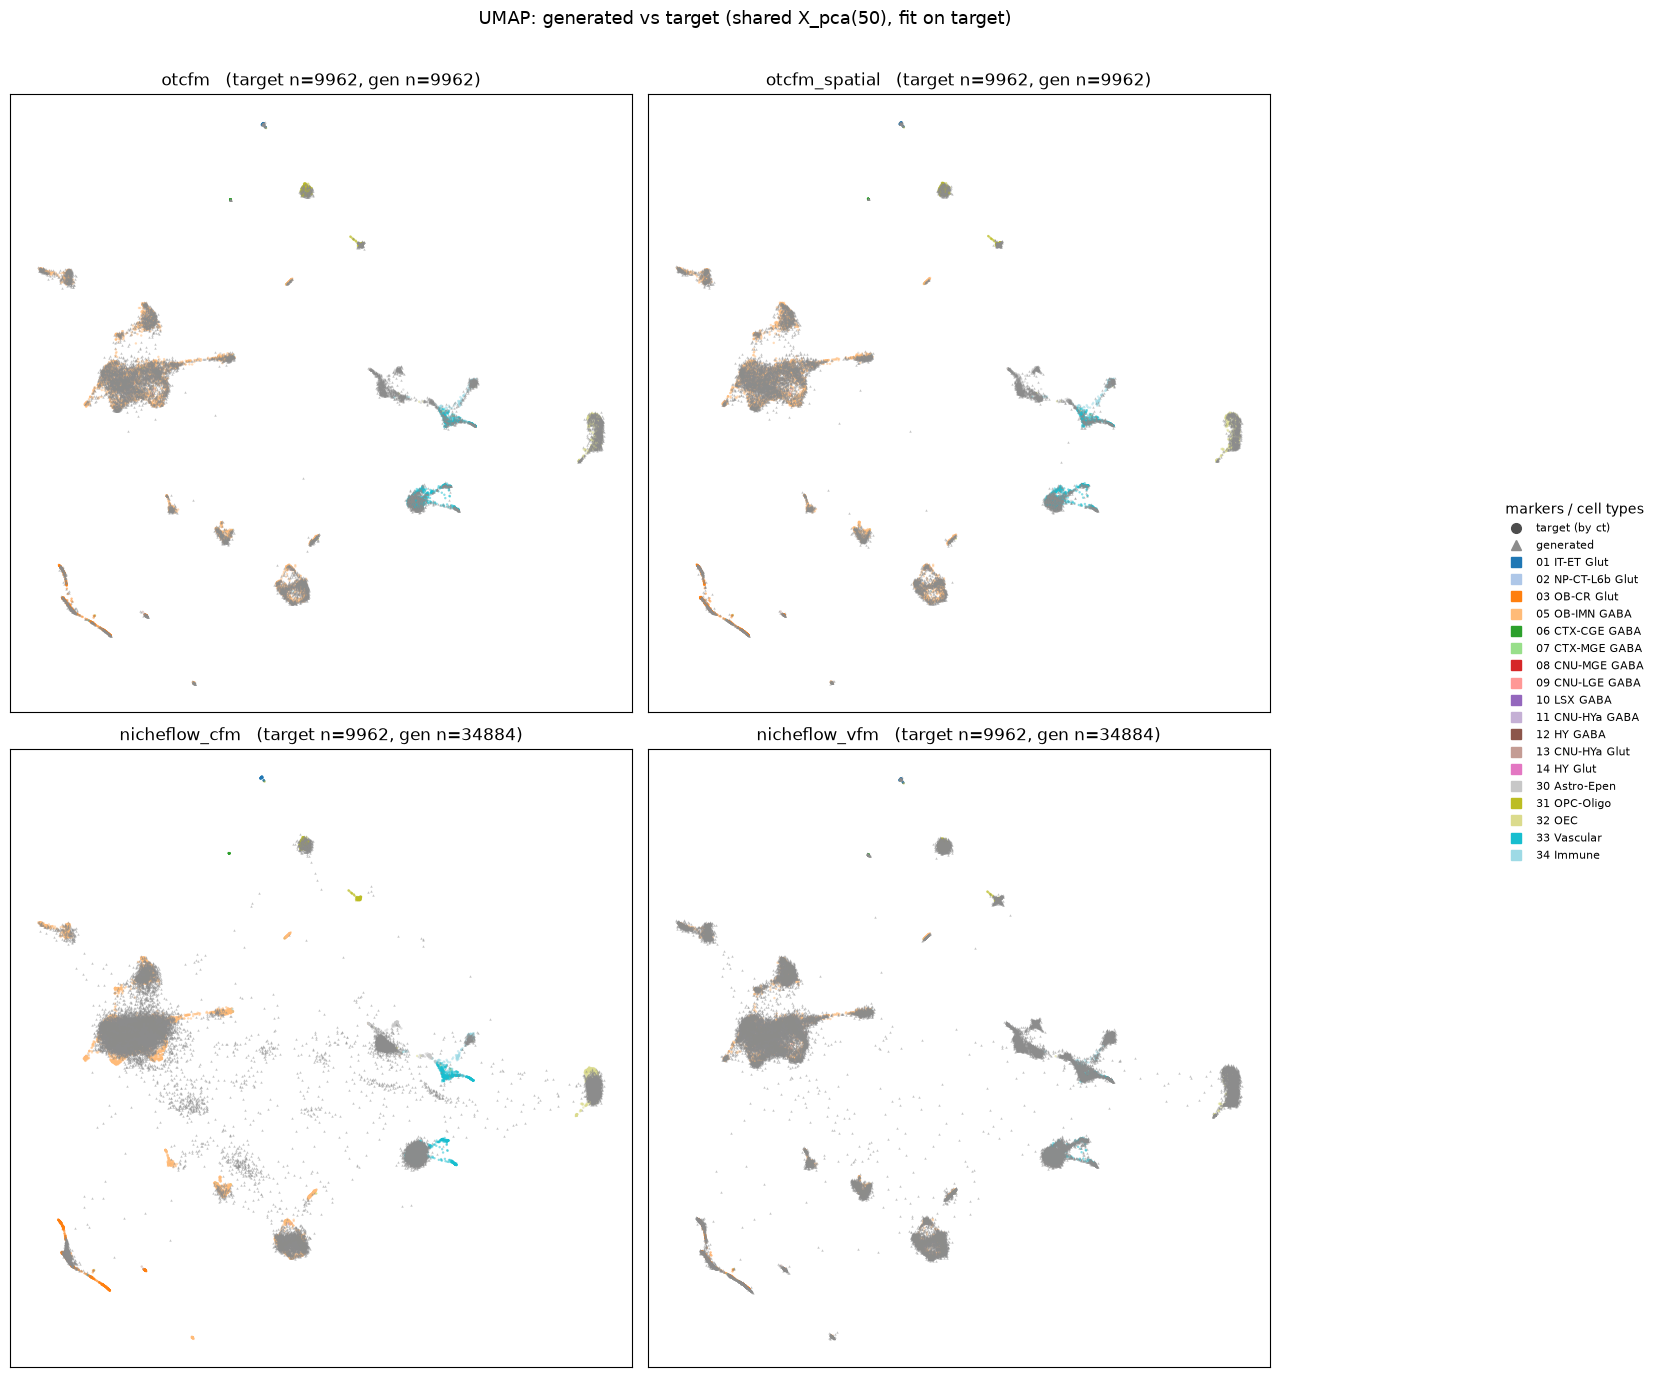

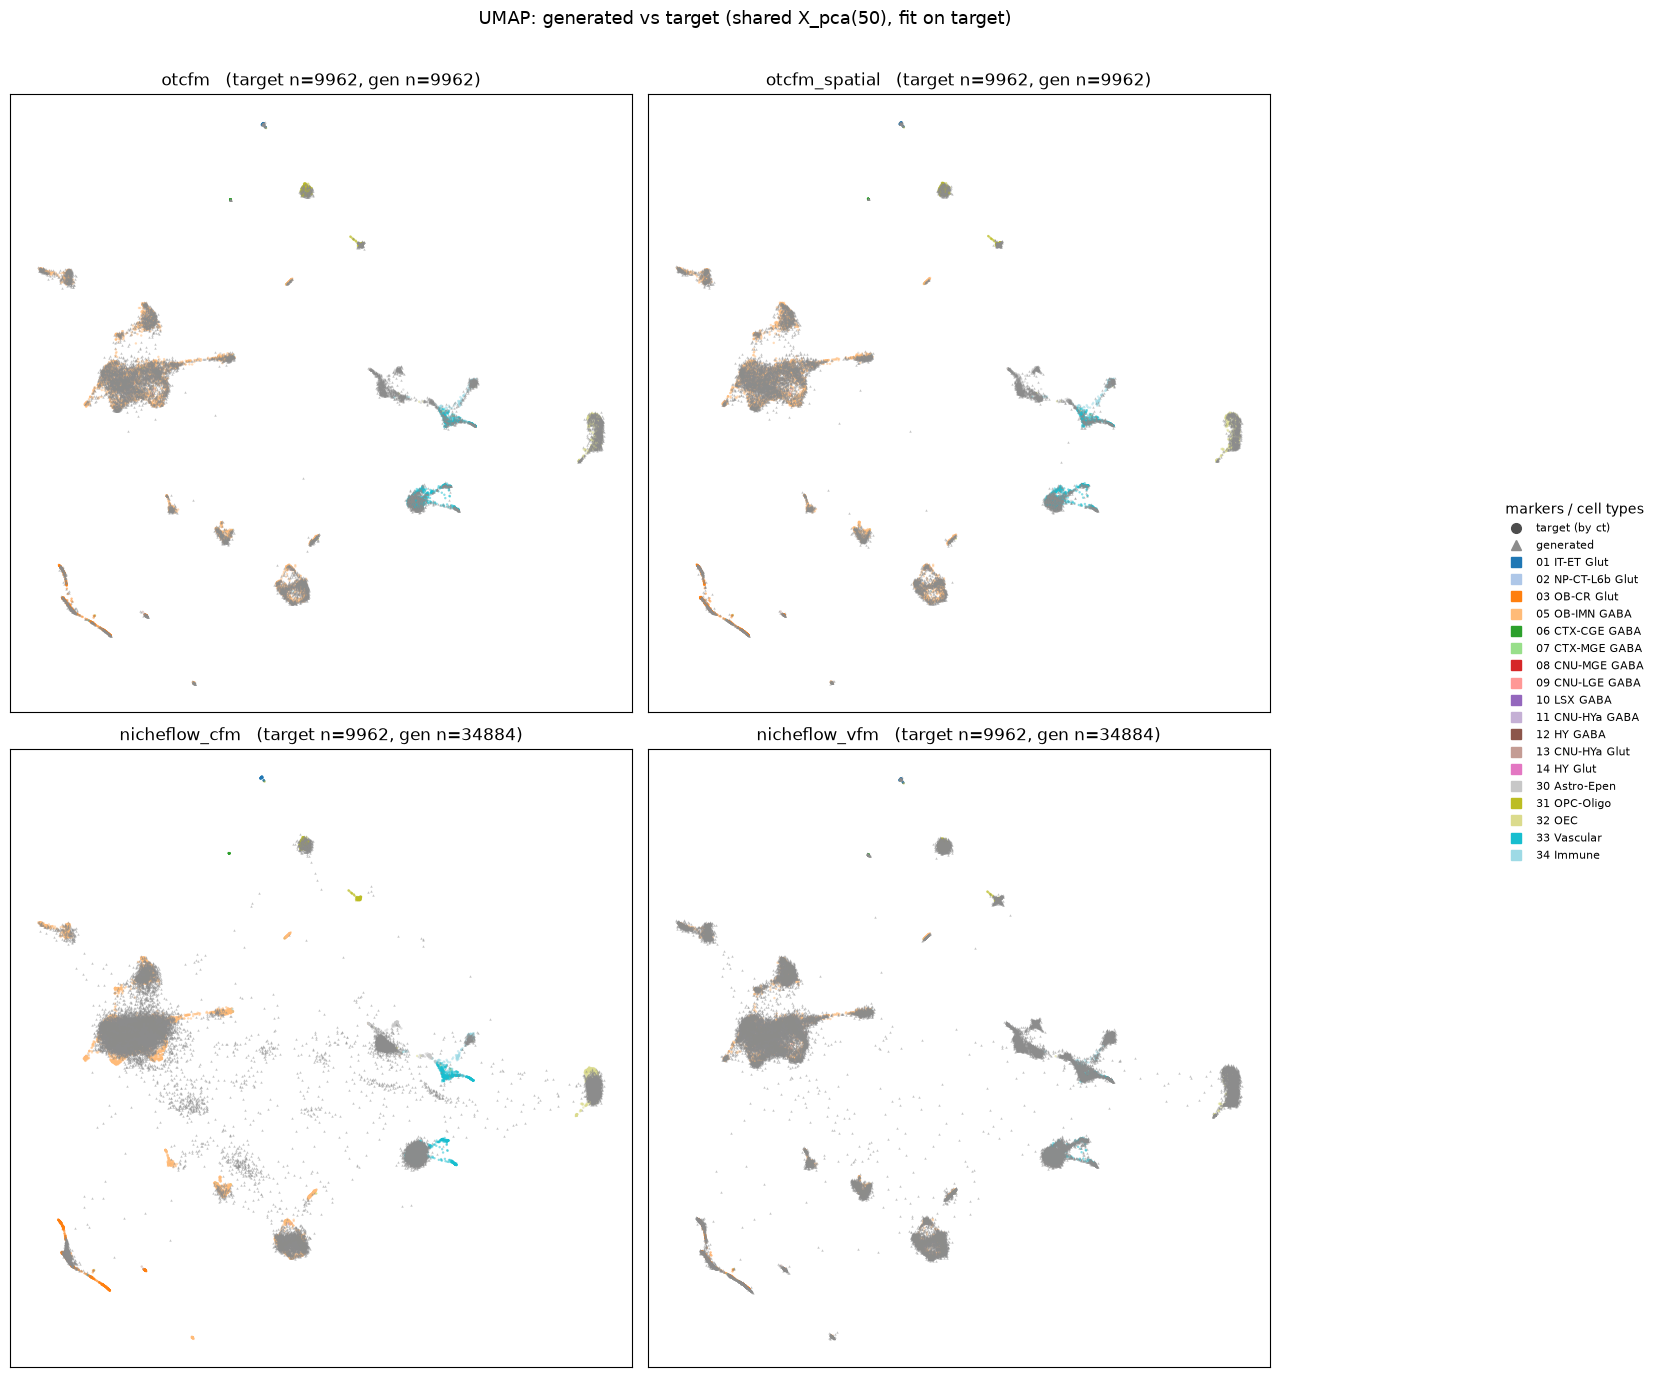

In [4]:
from paired_slides_eval.viz import umap_compare

MODELS = [
    ("otcfm",          "../artifacts/otcfm_shared50_1025/generated.h5ad"),
    ("otcfm_spatial",  "../artifacts/otcfm_spatial_shared50_1025/generated.h5ad"),
    ("nicheflow_cfm",  "../artifacts/nicheflow_cfm_unaligned/generated.h5ad"),
    ("nicheflow_vfm",  "../artifacts/nicheflow_vfm_unaligned/generated.h5ad"),
]

fig = umap_compare(
    "../data/abca_pair.pkl", MODELS,
    out_path="../reports/umap_compare.png",
    seed=0, point_size=3, alpha=0.5,   # lower point_size/alpha if the "all cells" plot is too dense
)
fig  # displays inline